![](ai_statement2.png)

# Problem 3.22

In [1]:
from scipy.constants import k, h, c, e
import numpy as np

@np.vectorize
def calculate_linewidth(wl, m=3.0, T=300):
    T=300
    return m*k*T*wl**2/(h*c)


wls = [850e-9, 1310e-9, 1550e-9]

print("wavelength   \t delta wavelength")
for wl in wls:
    print(f"{1e9*wl:.2f} nm \t {1e9*calculate_linewidth(wl, m=3.0)} nm") 

wavelength   	 delta wavelength
850.00 nm 	 45.19463790161044 nm
1310.00 nm 	 107.3474299002819 nm
1550.00 nm 	 150.2838997351129 nm


# Problem 3.23

(a)

(AlGaAs): m  = 2.7033109024624973
(GaAs): m  = 2.9682477608438007
(InGaAsP): m  = 3.229960536916881


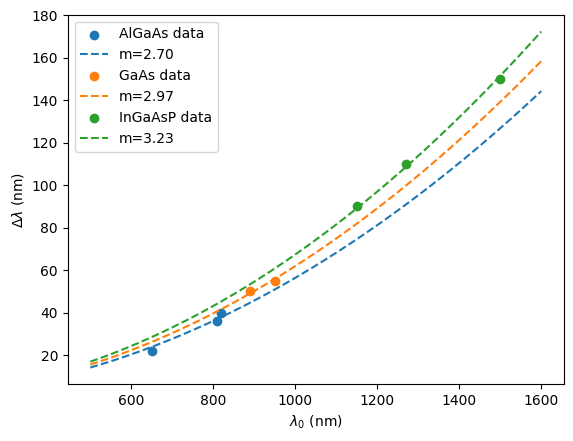

In [2]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares

linewidth_data = {
    "AlGaAs": {
        "wl0": 1.e-9*np.array([650, 810, 820]),
        "linewidth": 1.e-9*np.array([22, 36, 40])
    },
    "GaAs": {
        "wl0": 1.e-9*np.array([890, 950]),
        "linewidth": 1.e-9*np.array([50, 55])
    },
    "InGaAsP": {
        "wl0": 1.e-9*np.array([1150, 1270, 1500]),
        "linewidth": 1.e-9*np.array([90, 110, 150])
    }
}

wl = 1e-9*np.linspace(500, 1600, 1000)

for material, data in linewidth_data.items():
    popt, _ = curve_fit(calculate_linewidth, data["wl0"], data["linewidth"], p0=[4.0])
    plt.scatter(1e9*data["wl0"], 1e9*data["linewidth"], label=f"{material} data")
    plt.plot(1e9*wl, 1e9*calculate_linewidth(wl, m=popt[0]), label=f"m={popt[0]:.2f}", linestyle="--")
    print(f"({material}): m  = {popt[0]}")

plt.xlabel(r"$\lambda_0$ (nm)")
plt.ylabel(r"$\Delta \lambda$ (nm)")
plt.legend()

Really, the text asked for a single number for m, a numemrical constant not a material constant

m  = 3.151394037734424


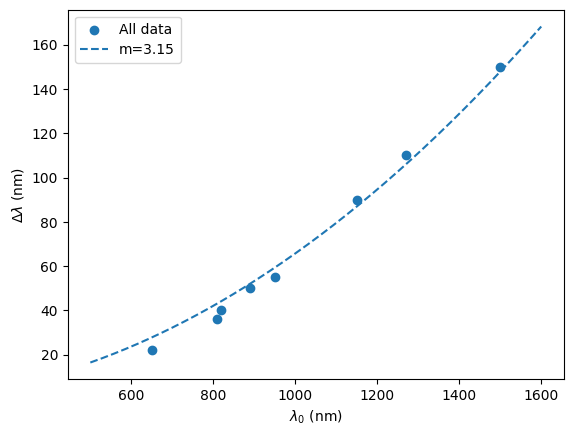

In [3]:
wl0 = 1e-9*np.array([650, 810, 820, 890, 950, 1150, 1270, 1500])
linewidth = 1e-9*np.array([22, 36, 40, 50, 55, 90, 110, 150])

popt, _ = curve_fit(calculate_linewidth, wl0, linewidth, p0=[3.0])
plt.scatter(1e9*wl0, 1e9*linewidth, label=f"All data")
plt.plot(1e9*wl, 1e9*calculate_linewidth(wl, m=popt[0]), label=f"m={popt[0]:.2f}", linestyle="--")
print(f"m  = {popt[0]}")
plt.legend()
plt.xlabel(r"$\lambda_0$ (nm)")
plt.ylabel(r"$\Delta \lambda$ (nm)")
plt.legend()

(b)

In [4]:
linewidth_data = {
    "GaP(N)": {
        "wl0": 1.e-9*np.array([565]),
        "linewidth": 1.e-9*np.array([28])
    },
    "GaAsP(N)": {
        "wl0": 1.e-9*np.array([583]),
        "linewidth": 1.e-9*np.array([36])
    },
    "GaAs(N)": {
        "wl0": 1.e-9*np.array([600]),
        "linewidth": 1.e-9*np.array([40])
    },
    "GaAsP": {
        "wl0": 1.e-9*np.array([635]),
        "linewidth": 1.e-9*np.array([40])
    },
}

print("λ (nm) \t\t True Δλ (nm) \t Expected Δλ (nm)")
for material, data in linewidth_data.items():
    print(f"{1e9*data["wl0"][0]:.4f} \t {1e9*data["linewidth"][0]:.2f} \t\t {1e9*calculate_linewidth(wl=data["wl0"][0], m=3, T=300)}")

λ (nm) 		 True Δλ (nm) 	 Expected Δλ (nm)
565.0000 	 28.00 		 19.968523576666563
583.0000 	 36.00 		 21.26112149721865
600.0000 	 40.00 		 22.519127535750535
635.0000 	 40.00 		 25.222986668341694


# Conclusion
The expected linewidth is within the same order of magnitude of the data, but their is a great degree of error, especially at higher frequencies.

IT is possible that there are sources of noise that contribute to the increased measured linewidth, such as heat, material impurity, etctera.

# Problem 3.29

Page 259 of the textbook defines PCE as  

![](pce.png)  

Page 258 defines IQE and EQE as  
![](_iqe.png)  
![](eqe.png)  

Page 259 deines the light extraction ratio as  
![](light_extraction_ratio.png)

In [5]:
def calculate_power_conversion_efficiency(P_out, I, V):
    return P_out / (I*V)

def calculate_internal_quantum_efficiency(tau_r, tau_nr):
    return (1/tau_r) / ((1/tau_r) + (1/tau_nr))

def calculate_external_quantum_efficiency(f, P_out, I):
    return (P_out / (h*f)) / (I / e)

def calculate_extraction_efficiency(f, P_out, eta_IQE, I): # light extraction ratio
    return P_out / (h*f*eta_IQE * I / e)

In [6]:
wl = 890e-9
f = c/wl
N_a = 4e17 # per cm^3
B = 1e-16
tau_r = 1 / (B*N_a*1e6) # See ex 3.14.1
tau_nr = 60e-9
I = 50e-3
V = 1.4
P_out = 10e-3

eta_PCE = calculate_power_conversion_efficiency(P_out, I, V)
eta_IQE = calculate_internal_quantum_efficiency(tau_r, tau_nr)
eta_EQE = calculate_external_quantum_efficiency(f, P_out, I)
eta_EE = calculate_extraction_efficiency(f, P_out, eta_IQE, I)

print(f"PCE: {eta_PCE}")
print(f"IQE: {eta_IQE}")
print(f"EQE: {eta_EQE}")
print(f"EE (light extraction ratio): {eta_EE}")

PCE: 0.14285714285714288
IQE: 0.7058823529411764
EQE: 0.14356668208481596
EE (light extraction ratio): 0.20338613295348928


# Example 3.14.1 (JUST FOR ME)

In [7]:
# wl = 870e-9
# f = c/wl
# N_a = 2e17 # per cm^3
# B = 2e-16
# tau_r = 1 / (B*N_a*1e6) # See ex 3.14.1
# tau_nr = 100e-9
# I = 30e-3
# V = 1.35
# P_out = 6.5e-3

# eta_PCE = calculate_power_conversion_efficiency(P_out, I, V)
# eta_IQE = calculate_internal_quantum_efficiency(tau_r, tau_nr)
# eta_EQE = calculate_external_quantum_efficiency(f, P_out, I)
# eta_EE = calculate_extraction_efficiency(f, P_out, eta_IQE, I)

# print(f"PCE: {eta_PCE}")
# print(f"IQE: {eta_IQE}")
# print(f"EQE: {eta_EQE}")
# print(f"EE (light extraction ratio): {eta_EE}")

# Problem 3.30

![](luminous_flux.png)
![](luminous_flux2.png)
![](luminous_efficacy.png)

This implies that 

$$ P_o = \Phi_{\nu} / (K \times V(\lambda)) $$

Where $K=633$ lm $W^{-1}$

To find the luminous efficiency of different wavelengths, $V(\lambda)$, we use filgure 3.41 in the text

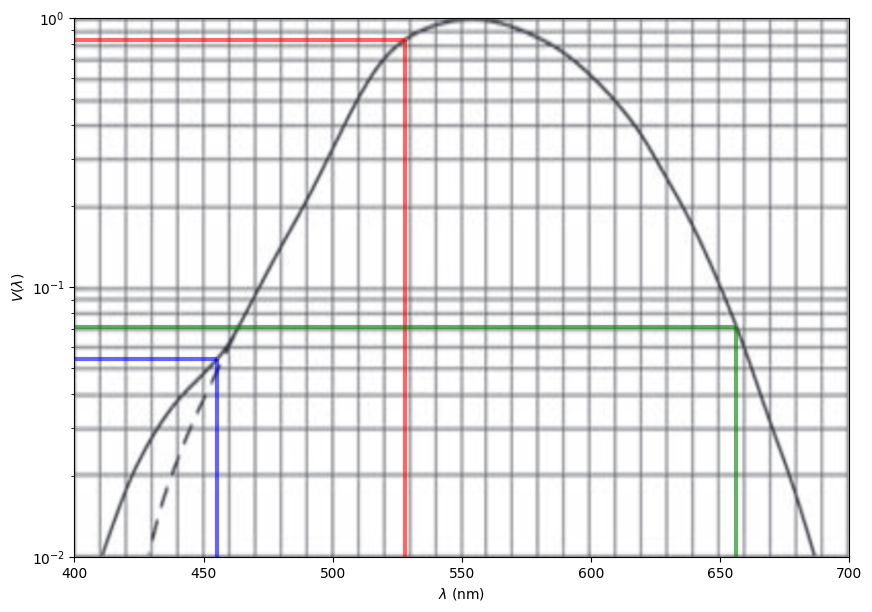

In [8]:
img = plt.imread("luminosity_function_cropped.png")
fig, ax = plt.subplots(figsize=(10, 7))


ax.set_xlim([400, 700])
ax.set_ylim([0.01, 1.0])
ax.set_yscale("log")

ax.set_ylabel(r"$V(\lambda)$")
ax.set_xlabel(r"$\lambda$ (nm)")

ax_tw_x = ax.twinx()
ax_tw_x.axis('off')
ax2 = ax_tw_x.twiny()
# plt.yscale('log')
ax2.axis('off')
ax2.imshow(img, extent=[0.01, 1, 400, 700],aspect="auto", zorder=10)

wl_a = 528e-9
wl_b = 656e-9
wl_c = 455e-9

luminosity_function_a = 0.83
luminosity_function_b = 0.071
luminosity_function_c = 0.054

ax.set_zorder(ax2.get_zorder()+1)
ax.patch.set_visible(False)
ax.vlines(1e9*wl_a, 0.01, luminosity_function_a, color="r", alpha=0.6, linewidth=3.0)
ax.hlines(luminosity_function_a, 400, 1e9*wl_a, color="r", alpha=0.6, linewidth=3.0)
ax.vlines(1e9*wl_b, 0.01, luminosity_function_b, color="g", alpha=0.6, linewidth=3.0)
ax.hlines(luminosity_function_b, 400, 1e9*wl_b, color="g", alpha=0.6, linewidth=3.0)
ax.vlines(1e9*wl_c, 0.01, luminosity_function_c, color="b", alpha=0.6, linewidth=3.0)
ax.hlines(luminosity_function_c, 400, 1e9*wl_c, color="b", alpha=0.6, linewidth=3.0)

In [9]:
def calculate_luminous_efficacy(P_nu, I, V):
    return P_nu / (I*V)

(a)

In [10]:
K = 633 # Standard value of K in lumens/Watt
Phi_nu = 92 # luminous flux (lumens)
I = 350e-3
V = 3.4
f = c / wl_a

P_out = Phi_e = Phi_nu / (K * luminosity_function_a)  # radiant flux
eta_PCE = calculate_power_conversion_efficiency(P_out, I, V)
eta_EQE = calculate_external_quantum_efficiency(f, P_out, I)
eta_LE = calculate_luminous_efficacy(Phi_nu, I, V)

print(f"Power Conversion Efficiency: {eta_PCE}")
print(f"External Quantum Efficiency: {eta_EQE}")
print(f"Luminous Efficacy: {eta_LE} lu/W")
print(f"Emitted Optical Power (radiant flux): {P_out} W")

Power Conversion Efficiency: 0.14714959243561526
External Quantum Efficiency: 0.21306178664593395
Luminous Efficacy: 77.31092436974791 lu/W
Emitted Optical Power (radiant flux): 0.17510801499838216 W


(b)

In [11]:
K = 633 # Standard value of K in lumens/Watt
P_out = Phi_e = 320e-3
Phi_nu = P_out * K * luminosity_function_b
I = 400e-3
V = 2.15
f = c / wl_b


eta_PCE = calculate_power_conversion_efficiency(P_out, I, V)
eta_EQE = calculate_external_quantum_efficiency(f, P_out, I)
eta_LE = calculate_luminous_efficacy(Phi_nu, I, V)

print(f"Power Conversion Efficiency: {eta_PCE}")
print(f"External Quantum Efficiency: {eta_EQE}")
print(f"Luminous Efficacy: {eta_LE} lu/W")

Power Conversion Efficiency: 0.37209302325581395
External Quantum Efficiency: 0.42327974583208666
Luminous Efficacy: 16.722976744186045 lu/W


(c)

In [12]:
K = 633 # Standard value of K in lumens/Watt
P_out = Phi_e = 710e-3
Phi_nu = P_out * K * luminosity_function_c
I = 350e-3
V = 3.2
f = c / wl_c


eta_PCE = calculate_power_conversion_efficiency(P_out, I, V)
eta_EQE = calculate_external_quantum_efficiency(f, P_out, I)
eta_LE = calculate_luminous_efficacy(Phi_nu, I, V)

print(f"Power Conversion Efficiency: {eta_PCE}")
print(f"External Quantum Efficiency: {eta_EQE}")
print(f"Luminous Efficacy: {eta_LE} lu/W")

Power Conversion Efficiency: 0.6339285714285715
External Quantum Efficiency: 0.7444497054173322
Luminous Efficacy: 21.668946428571427 lu/W


# Problem 4.1

(a)  
Let $N_1$ and $N_2$ denote the concentration (per volume) of $Cr^{3+}$ ions at $E_1$ and $E_2$, respectively. Let $N_0$ denote the total number of $Cr^{3+}$ ions. The threshold for population inversion occurs when half of the $Cr^{3+}$ ions are present in $E_2$, thus:

$$ N_1 = N_2 = N_0/2 $$





The total number of $Cr^{3+}$ ions at $E_2$ in a volume $V$ is therefore $V N_2 = V N_0/2$. Let $\tau_{13}$. $\tau_{32}$, and $\tau_{sp}$ denote the time it takes for $Cr^{3+}$ ions to transition from $E_1$ to $E_3$, $E_3$ to $E_2$, and $E_2$ to $E_1$, respectively. The rate at which $Cr^{3+}$ ions make a roundtrip through the three states is clearly $\tau_{total} = \tau_{13} + \tau_{32} + \tau_{sp}$. Since $ \tau_{sp} >> \tau_{13}, \tau_{32}$, clearly the rate at which a single $Cr^{3+}$ ion makes a roundtrip is $\frac{1}{\tau_{total}} \approx \frac{1}{\tau_{sp}}$. This implies that the number of ions that must transition from $N_1$ to $N_2$ per second is $(N_0/2)\times \frac{1}{\tau_{sp}}$ ions per second. 

Each time a $Cr^{3+}$ ion makes a transition from $E_1$ to $E_3$, it emits a photon with energy $h\nu_{13}$. Therefore, the total energy of $N_0/2$ transitions is $N_0/2 \times h\nu_{13}$ per volume. where $\nu_{13}$ is the pump frequency. Since these transitions occur $(N_0/2)\times \frac{1}{\tau_{sp}}$ times a second, the total power supplied by the pump is clearly  $P_p = V(N_0/2) h\nu_{13} /\tau_{sp}$, where V is the volume.

(b)

In [13]:
def min_power_pump(f_p, V=1.92e-6, N_0=1e20, tau_sp=3e-3):
    return V*(N_0/2)*h*f_p / tau_sp

In [ ]:
L = 50e-3
diameter = 7e-3
V = np.pi*(diameter/2)**2 * L * (1e6)
E_p = 3 * e # Joules in 3 electron volts
f_p = E_p / h
P_p = min_power_pump(f_p, V=V, N_0=1e20, tau_sp=3e-3)

print(f"Min Power of Pump = {1e-3*P_p:.1f} kW")

Min Power of Pump = 15.4 kW


1.9242255003237485

# Problem 5.1
If the irradiance of light doubles after passing once through a laser amplifier 0.5 m long, calculate the small signal gain coefficient k assuming no losses. If the increase in irradiance were only 5%, what would k be? 

![](small_signal_gain.png)
![](small_signal_gain_equation.png)

I am assuming that the "small signal gain" just corresponds to normal gain of a LASER in eq 4.2.20, where saturation effects are ignored. This is analogous to the eq 4.3.7.

$$ G = exp(gL) $$
$$ 2 = exp(g\times0.5),\space recall \space G = I(L)/I(0) $$
$$ g = ln(2)/0.5 $$
Assuming g = k  

$$ k = g = 1.38 \space [m^{-1}] $$


If the increase in irradiance were only 5%, this implies $G=1.05$

$$ 1.05 = exp(g*0.5) $$
$$ g = ln(1.05)/0.5 $$
$$ g=0.09758 \space [m^{-1}] $$

I found this equation from wilson and Hawkes

![](small_signal_gain_k_wilson_and_hawkes.png)

Since $B_{12} = B_{21}$, $g_1 = g_2$

# Problem 5.2
Calculate the degree of population inversion required to give a small signal gain coefficient for a CO2 laser (λ=10.6 μm) of 0.5 m-1. Take the Einstein A coefficient for the upper laser level to be     200 s-1. 

According to Planck's Law (Also, see page 298 in textbook)
$$ \frac{A_{21}}{B_{21}} = \frac{8\pi h \nu^3 n^3}{c^3} $$
$$ g(\nu) = (N_2 - N_1)B_{21}\frac{nh\nu}{c\Delta\nu} $$

$$ \rho_\nu = \frac{A_{21}/B_{21}}{exp[(E_2 - E_1)/(K_B T)] - 1}  $$
$$ \rho_\nu = \frac{A_{21}/B_{21}}{N_1/N_2 - 1}  $$

Using the Wilson and Hawkes equation for small signal gain, with $\frac{g_2}{g_1} = 1$, we obtain the expression

$$ k = (N_2 - N_1)B_{21}\frac{h\nu_{21}n}{c} $$

rearranging, we obtain
$$ (N_2 - N_1) = \frac{k}{(B_{21})} \frac{c}{h\nu_{21}n} $$

$$ (N_2 - N_1) = \frac{8\pi h \nu^3 n^3}{A_{21}c^3} \frac{kc}{h\nu_{21}n} $$
$$ (N_2 - N_1) = \frac{8\pi h \nu^3 n^2}{A_{21}c^2} \frac{k}{h\nu_{21}} $$


In [15]:
k = 0.5 # meters^-1
wl = 10.6e-6 # meters
f = c/wl # hz
A_21 = 200 # second^-1
n = 1.00045 # Refractive index of CO2 gas


B_21 = A_21*c**3 / (8*np.pi*h*f**3*n**3)

# population_inversion = 8*np.pi*h*f**2 * n**2 / (A_21*c**2) * k / (h) *1e-6 # per cubic cm
population_inversion = k/B_21 * c/(h*f*n)
print(f"N_2 - N_1 = {"{:f}".format(population_inversion*1e-10)}x10^10 per cubic centimeter")


N_2 - N_1 = 0.055970x10^10 per cubic centimeter


In [16]:
# Just checking my answer
B_21 = c**3 / (8*np.pi * h * f**3 * n**3) * A_21
print(population_inversion * B_21 * h * f * n / c )

0.5


A more thorough treatment of this problem would take into account the linewidth the laser.

$$ g(f) = (N_2 - N_1)B_{21}\frac{nhf}{c\Delta f} $$

From eq 4.5.3

$$ \Delta f = 2f_0 \sqrt{\frac{2K_B T ln(2)}{M c^2}}$$

Where M is the mass of the lasing atom or molecule

therefore 

$$ (N_2 - N_1) = k / B_{21} * c \Delta f / (n h f) $$


In [17]:
from scipy.constants import Boltzmann as K_B
T = 300
T = 400 # Assume discharge temp of 127 degrees C as in ex 4.5.1
M = 44.009 /( 6.022*1e23) # grams
M = 1e-3*44.009 /( 6.022*1e23) # kilograms
delta_f = 2 * f * np.sqrt(2*K_B*T*np.log(2)/ (M*c**2))

population_inversion = k*c*delta_f/(B_21*n*h*f)*1e-6 # cm^-3
print(f"(N_2 - N_1) = {population_inversion*1e-10}x10^10 per cubic centimeter")

(N_2 - N_1) = 3.418078527930016x10^10 per cubic centimeter


# Problem 5.3
Calculate the mirror reflectances required to sustain laser oscillations in a laser which is 0.1 m long, given that the small signal gain coefficient is 1 m-1 (assume the mirrors have the same values of reflectance).

$$g_{th} = \gamma + \frac{1}{2L}ln(\frac{1}{R_1R_2}) $$

Assume $\gamma = 0$ and $R_1 = R_2 = R$

$$1 = 0 + \frac{1}{2L}ln(\frac{1}{R^2}) $$

$$ 2L = ln(\frac{1}{R^2}) $$

$$ exp(2L) = \frac{1}{R^2} $$
$$ R^2 = exp(-2L) $$
$$ R = \sqrt{exp(-2L)} $$

In [18]:
L = 0.1
R = np.sqrt(np.exp(-2*L))

print(f"Reflectance: {R}")

Reflectance: 0.9048374180359595
